In [1]:
# Cell 1: Imports and Setup
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Import our custom modules
from model import SimpleVGG
from dataset import get_cifar10_dataloaders

# Setup
device = "cuda" if torch.cuda.is_available() else "cpu"
sns.set(style="whitegrid", font_scale=1.2)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [2]:
device

'cuda'

In [5]:
# Cell 2: Load Model and Test Data
# IMPORTANT: We only need the test_loader here.
# We create a new set of data loaders but only use the test portion.
_, _, test_loader = get_cifar10_dataloaders(batch_size=128)

# Initialize the model structure
model = SimpleVGG(num_classes=10).to(device)

# Load the saved state dictionary from our best training epoch
model_path = 'best_cifar10_vgg.pth'
model.load_state_dict(torch.load(model_path))

# Crucially, set the model to evaluation mode
model.eval()
print("Model loaded successfully and set to evaluation mode.")

Full training set size: 50000
Training set size: 45000
Validation set size: 5000
Test set size: 10000
Model loaded successfully and set to evaluation mode.


--- Classification Report ---
              precision    recall  f1-score   support

       plane       0.90      0.83      0.87      1000
         car       0.95      0.91      0.93      1000
        bird       0.81      0.81      0.81      1000
         cat       0.78      0.69      0.73      1000
        deer       0.80      0.90      0.85      1000
         dog       0.78      0.82      0.80      1000
        frog       0.90      0.89      0.89      1000
       horse       0.91      0.88      0.89      1000
        ship       0.91      0.94      0.92      1000
       truck       0.88      0.94      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



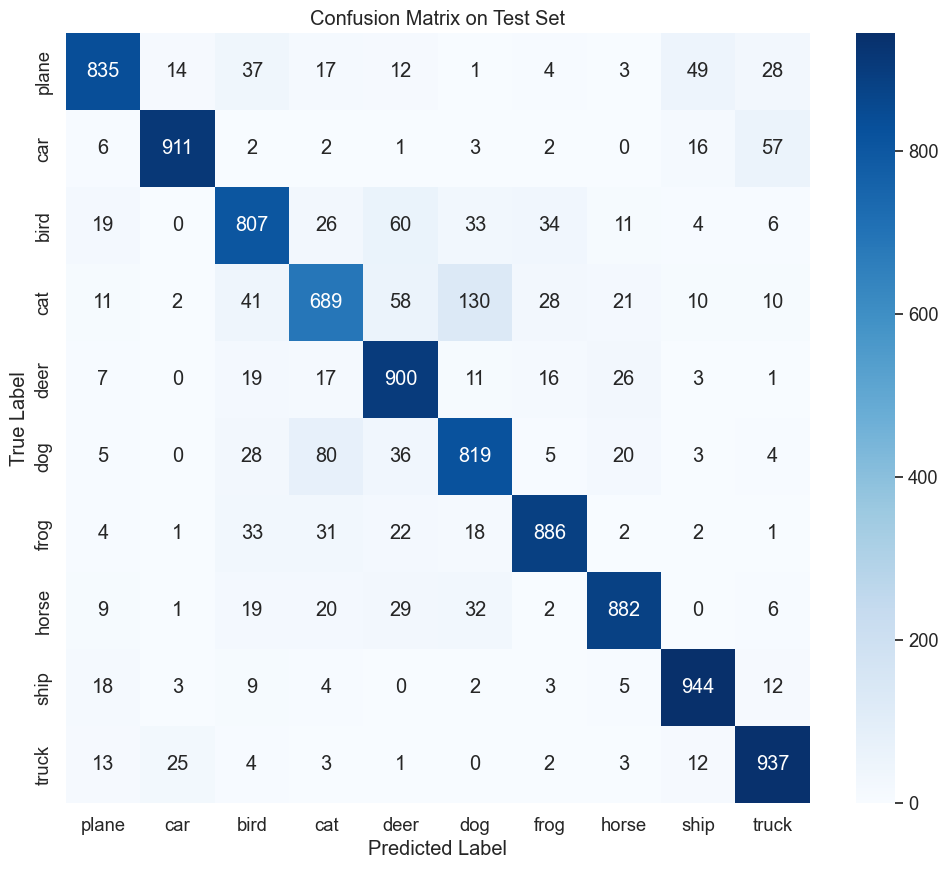

In [6]:
# Cell 3: Final Unbiased Evaluation on Test Set
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Generate and print the classification report
print("--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=classes))

# Plot the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


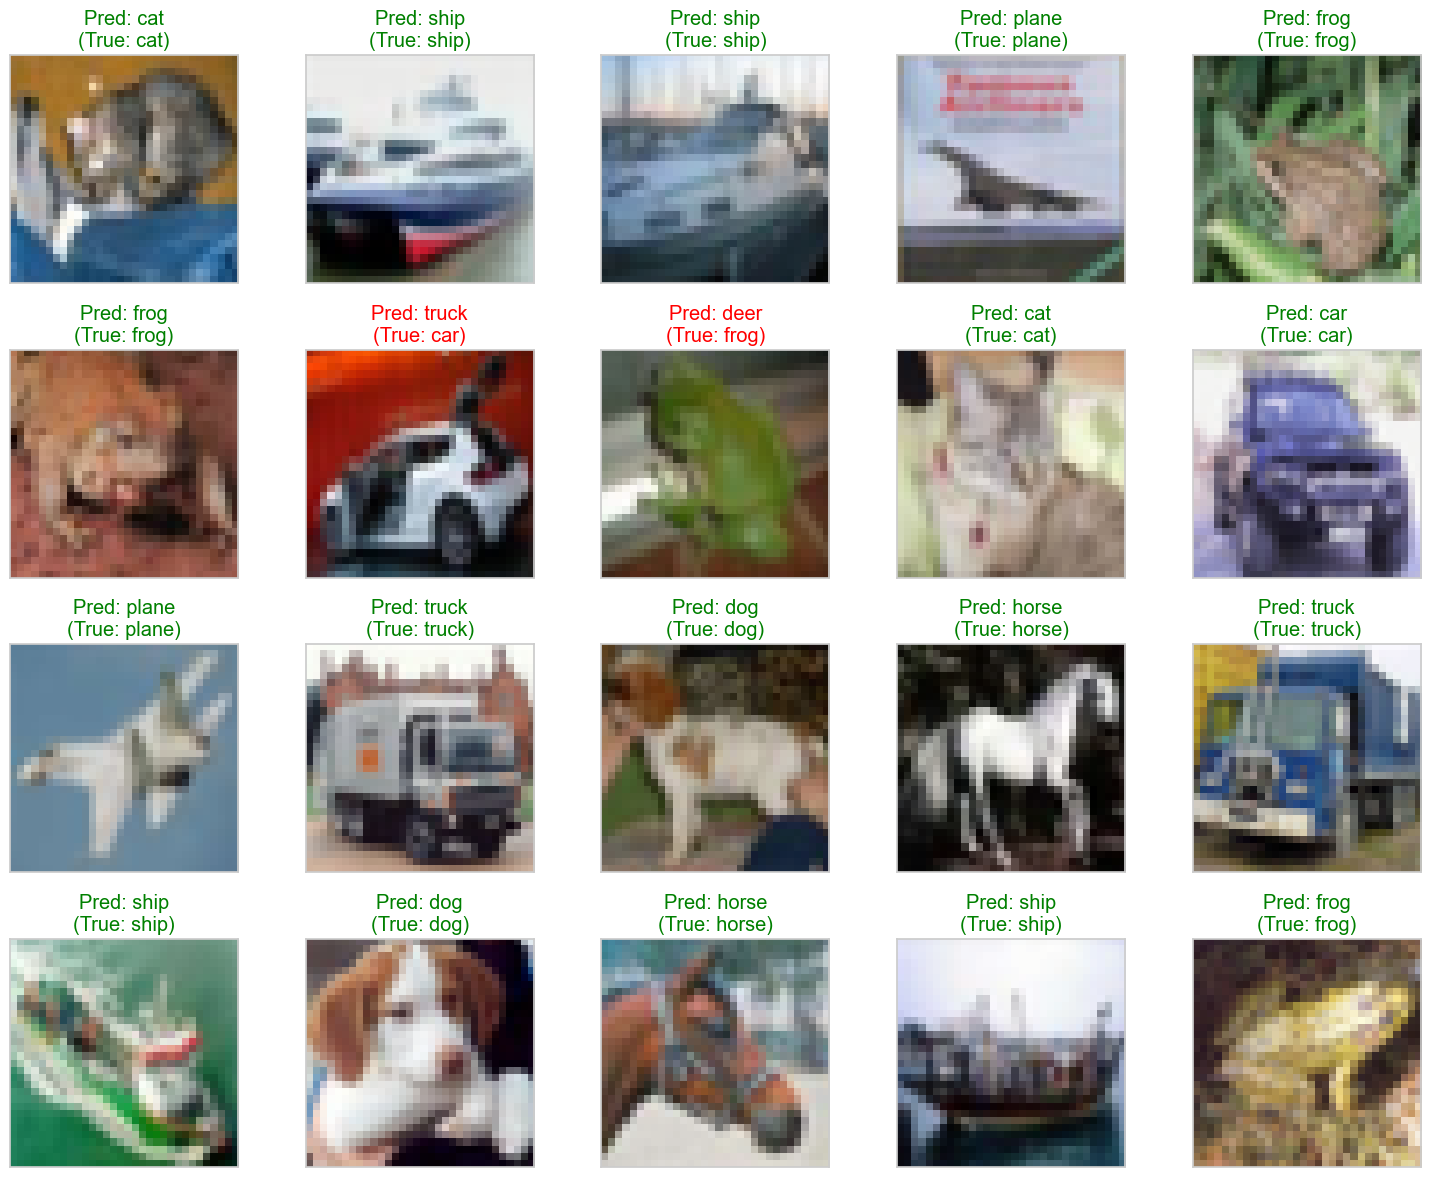

In [7]:
# Cell 4: Visualizing Sample Predictions (Successes and Failures)
def visualize_predictions(model, data_loader, num_images=20):
    model.eval()
    images, labels = next(iter(data_loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu().numpy()
    
    # Un-normalize for visualization
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    
    fig = plt.figure(figsize=(15, 12))
    for idx in np.arange(num_images):
        ax = fig.add_subplot(4, 5, idx+1, xticks=[], yticks=[])
        
        img = images[idx]
        img = np.transpose(img, (1, 2, 0)) # C, H, W -> H, W, C
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        
        color = "green" if preds[idx] == labels[idx] else "red"
        ax.set_title(f"Pred: {classes[preds[idx]]}\n(True: {classes[labels[idx]]})", color=color)
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader)

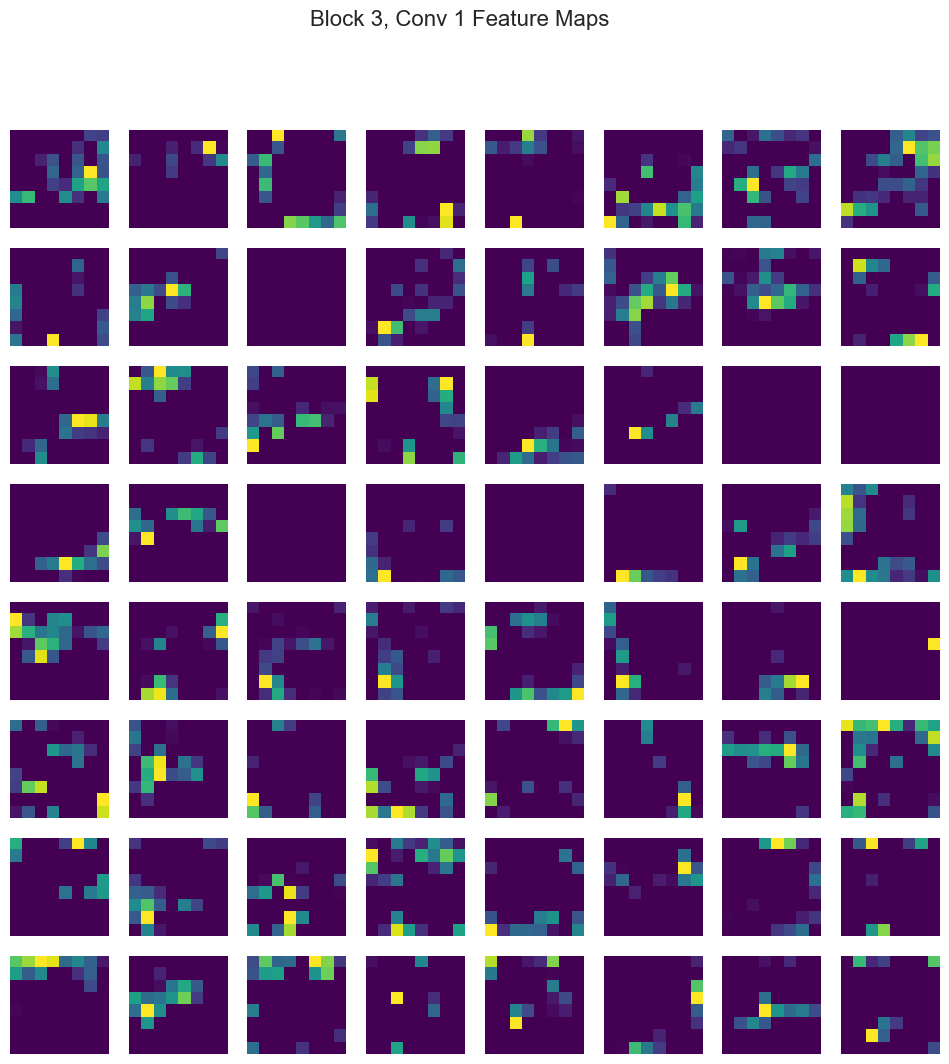

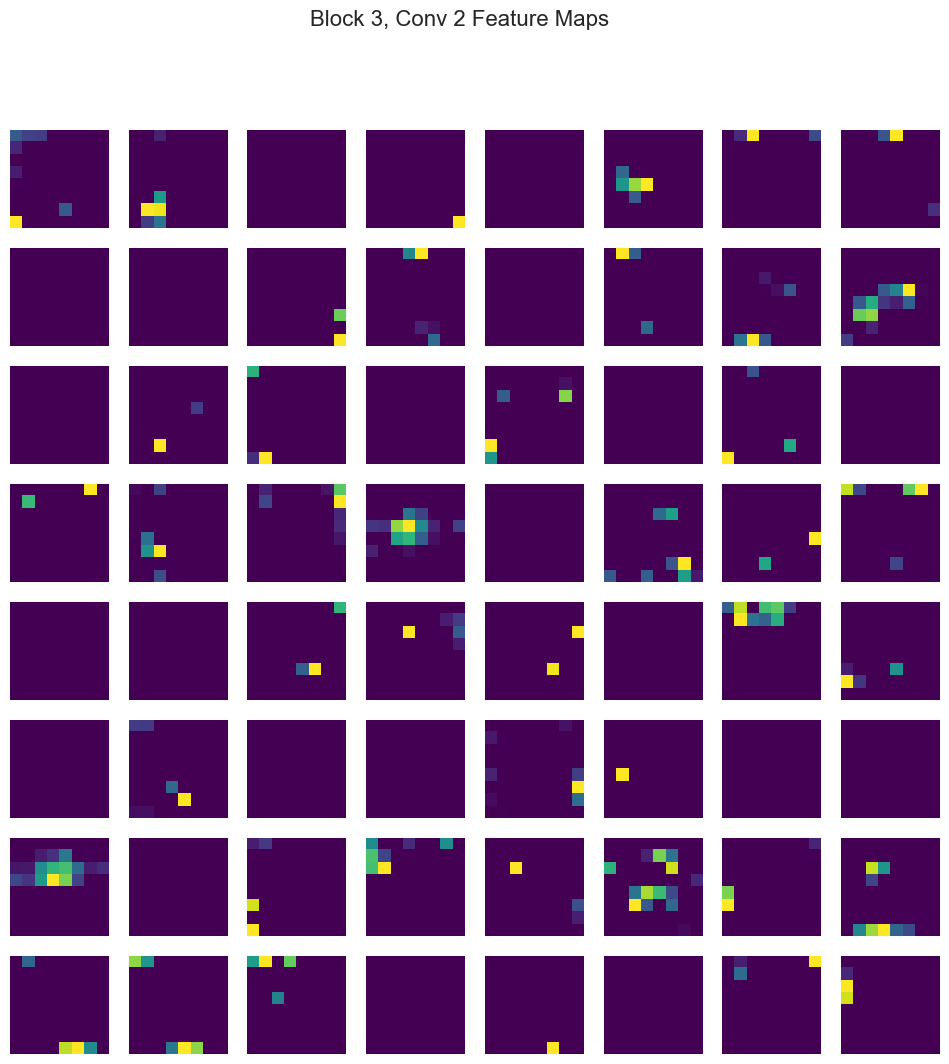

Observation: Notice how the activations become more abstract and less visually interpretable in deeper layers. Early layers might detect edges, while these deeper layers detect more complex patterns or object parts.


In [8]:
# We use "hook into" the forward pass and grab intermediate outputs

activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook


# Let's inspect the output of the first and last convolutional layers in block 3
model.block3[0].register_forward_hook(get_activation('block3_conv1'))
model.block3[2].register_forward_hook(get_activation('block3_conv2'))

# Get a single image and pass it through the model
image, _ = next(iter(test_loader))
image = image[0:1].to(device) # Take one image, keep batch dim
_ = model(image)

# Plot the feature maps from the first conv layer in block 3
act = activation['block3_conv1'].squeeze()
fig, axarr = plt.subplots(8, 8, figsize=(12, 12))
fig.suptitle('Block 3, Conv 1 Feature Maps', fontsize=16)
for idx in range(min(act.size(0), 64)):
    ax = axarr[idx // 8, idx % 8]
    ax.imshow(act[idx].cpu().numpy(), cmap='viridis')
    ax.axis('off')
plt.show()

# Plot the feature maps from the second conv layer in block 3
act = activation['block3_conv2'].squeeze()
fig, axarr = plt.subplots(8, 8, figsize=(12, 12))
fig.suptitle('Block 3, Conv 2 Feature Maps', fontsize=16)
for idx in range(min(act.size(0), 64)):
    ax = axarr[idx // 8, idx % 8]
    ax.imshow(act[idx].cpu().numpy(), cmap='viridis')
    ax.axis('off')
plt.show()

print("Observation: Notice how the activations become more abstract and less visually interpretable in deeper layers. Early layers might detect edges, while these deeper layers detect more complex patterns or object parts.")